## Titanic (kaggle)

In [1]:
import sys
from pathlib import Path

In [2]:
sys.path.append(str(Path().resolve().parent))

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
from src.features import FeatureEngineer
from src.utils import draw_phik_matrix

from configs import config

%matplotlib inline
%load_ext autoreload 
%autoreload 2

/Users/ruslan/ML experiiment VADIM/Titanic(kaggle)/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### EDA

In [4]:
df = pd.read_csv(config.paths.path_to_train_data)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
report = sv.analyze(df)
report.show_html("df_report.html")

Feature: PassengerId                         |▊         | [  8%]   00:00 -> (00:00 left)

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)


Report df_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [8]:
df[df['Fare']==0].shape

(15, 12)

Выводы:
- survived не сбалансирован, надо использовать стратификацию
- passanger_id не несет информацию - удалить
- необходимо заполнить пропуски в age(20%) и embarked (<1%), безлайн - заполнить медианой и частым
- ticket текстовый возможно номер несет информацию, инициалы возможно несут информацию
- cabin текстовый, надо вытащить класс и номер кабины
- name может можно будет вытащить статус


In [9]:

from src.features import FeatureEngineer
fe = FeatureEngineer()
df_fe = fe.fit_transform(df)
df_fe.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Big_family,Title,Age_was_missing,AgeGroup,WomanOrChild,Fare_per_person,Age_class,Fare_class,Name_length,Fare_log
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,0,Mr,0,YoungAdult,0,3.62500,66.0,21.7500,23,2.110213
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,0,Mrs,0,Adult,1,35.64165,38.0,71.2833,51,4.280593
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,0,Miss,0,YoungAdult,1,7.92500,78.0,23.7750,22,2.188856
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,0,Mrs,0,YoungAdult,1,26.55000,35.0,53.1000,44,3.990834
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,0,Mr,0,YoungAdult,0,8.05000,105.0,24.1500,24,2.202765


In [10]:
report = sv.analyze(df_fe)
report.show_html("df_fe_report.html")

Feature: PassengerId                         |▍         | [  4%]   00:00 -> (00:00 left)

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:03 -> (00:00 left)


Report df_fe_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [11]:
df_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   PassengerId      891 non-null    int64   
 1   Survived         891 non-null    int64   
 2   Pclass           891 non-null    int64   
 3   Name             891 non-null    str     
 4   Sex              891 non-null    str     
 5   Age              891 non-null    float64 
 6   SibSp            891 non-null    int64   
 7   Parch            891 non-null    int64   
 8   Ticket           891 non-null    str     
 9   Fare             891 non-null    float64 
 10  Cabin            891 non-null    str     
 11  Embarked         891 non-null    str     
 12  Family           891 non-null    int64   
 13  Is_alone         891 non-null    int64   
 14  Big_family       891 non-null    int64   
 15  Title            891 non-null    str     
 16  Age_was_missing  891 non-null    int64   
 17  AgeGroup

In [12]:
df_fe.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Family', 'Is_alone',
       'Big_family', 'Title', 'Age_was_missing', 'AgeGroup', 'WomanOrChild',
       'Fare_per_person', 'Age_class', 'Fare_class', 'Name_length',
       'Fare_log'],
      dtype='str')

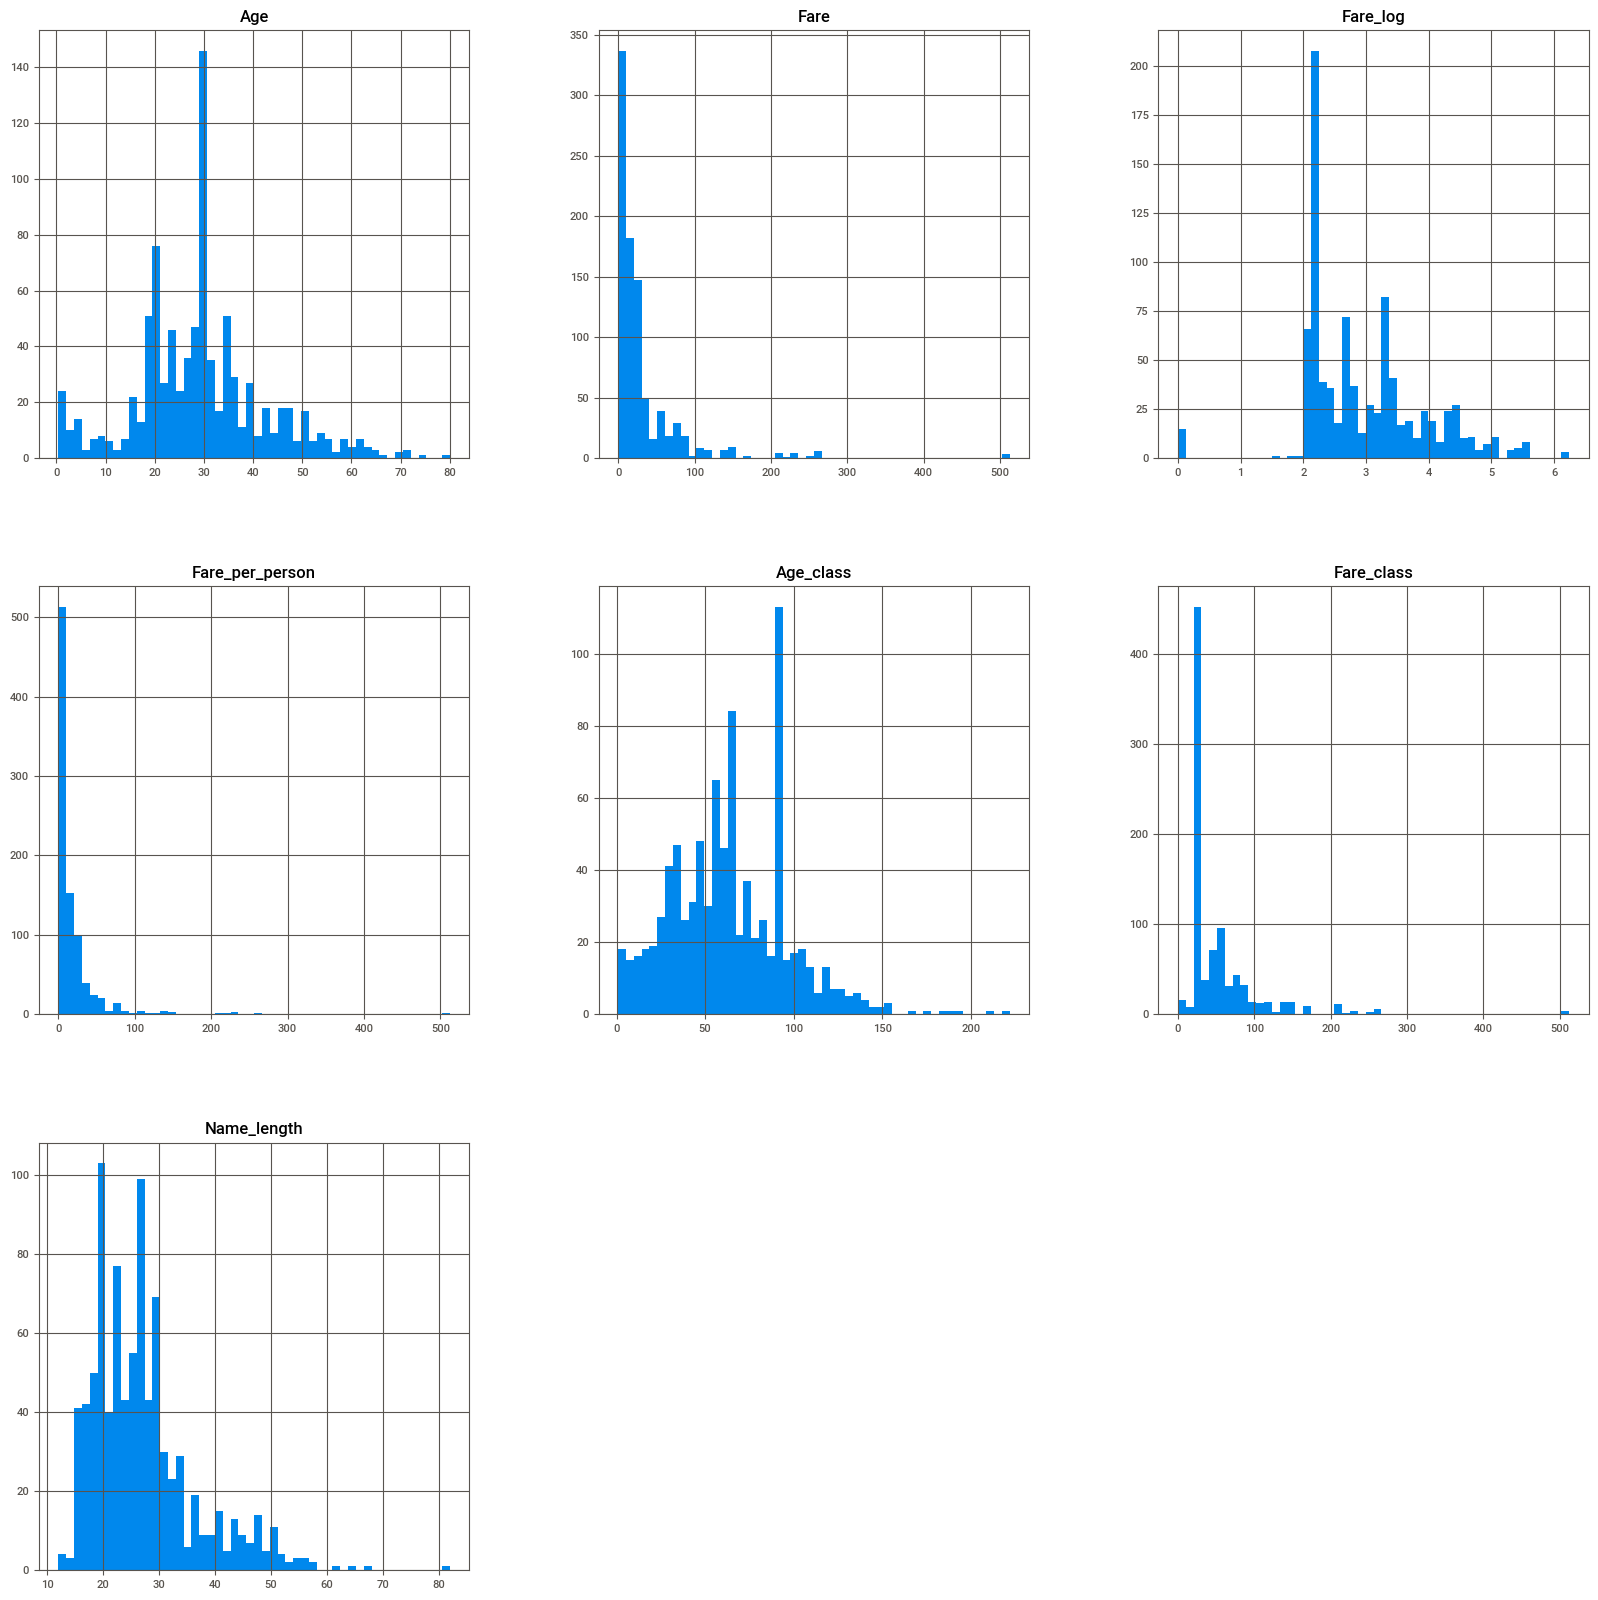

In [13]:
num_cols = [
    'Age',
    'Fare',
    'Fare_log',
    'Fare_per_person',
    'Age_class',
    'AgeGroup',
    'Fare_class',
    'Name_length',
]


cat_cols =[
    'Pclass',  
    'Sex', 
    'SibSp',
    'Parch',  
    'Cabin', 
    'Embarked', 
    'Family', 
    'Is_alone',
    'Big_family',  
    'Age_was_missing',  
    'WomanOrChild',
]
# num_columns =  df_fe.select_dtypes(include='number').columns.tolist()
df_fe[num_cols].hist(bins=50, figsize=(20, 20));

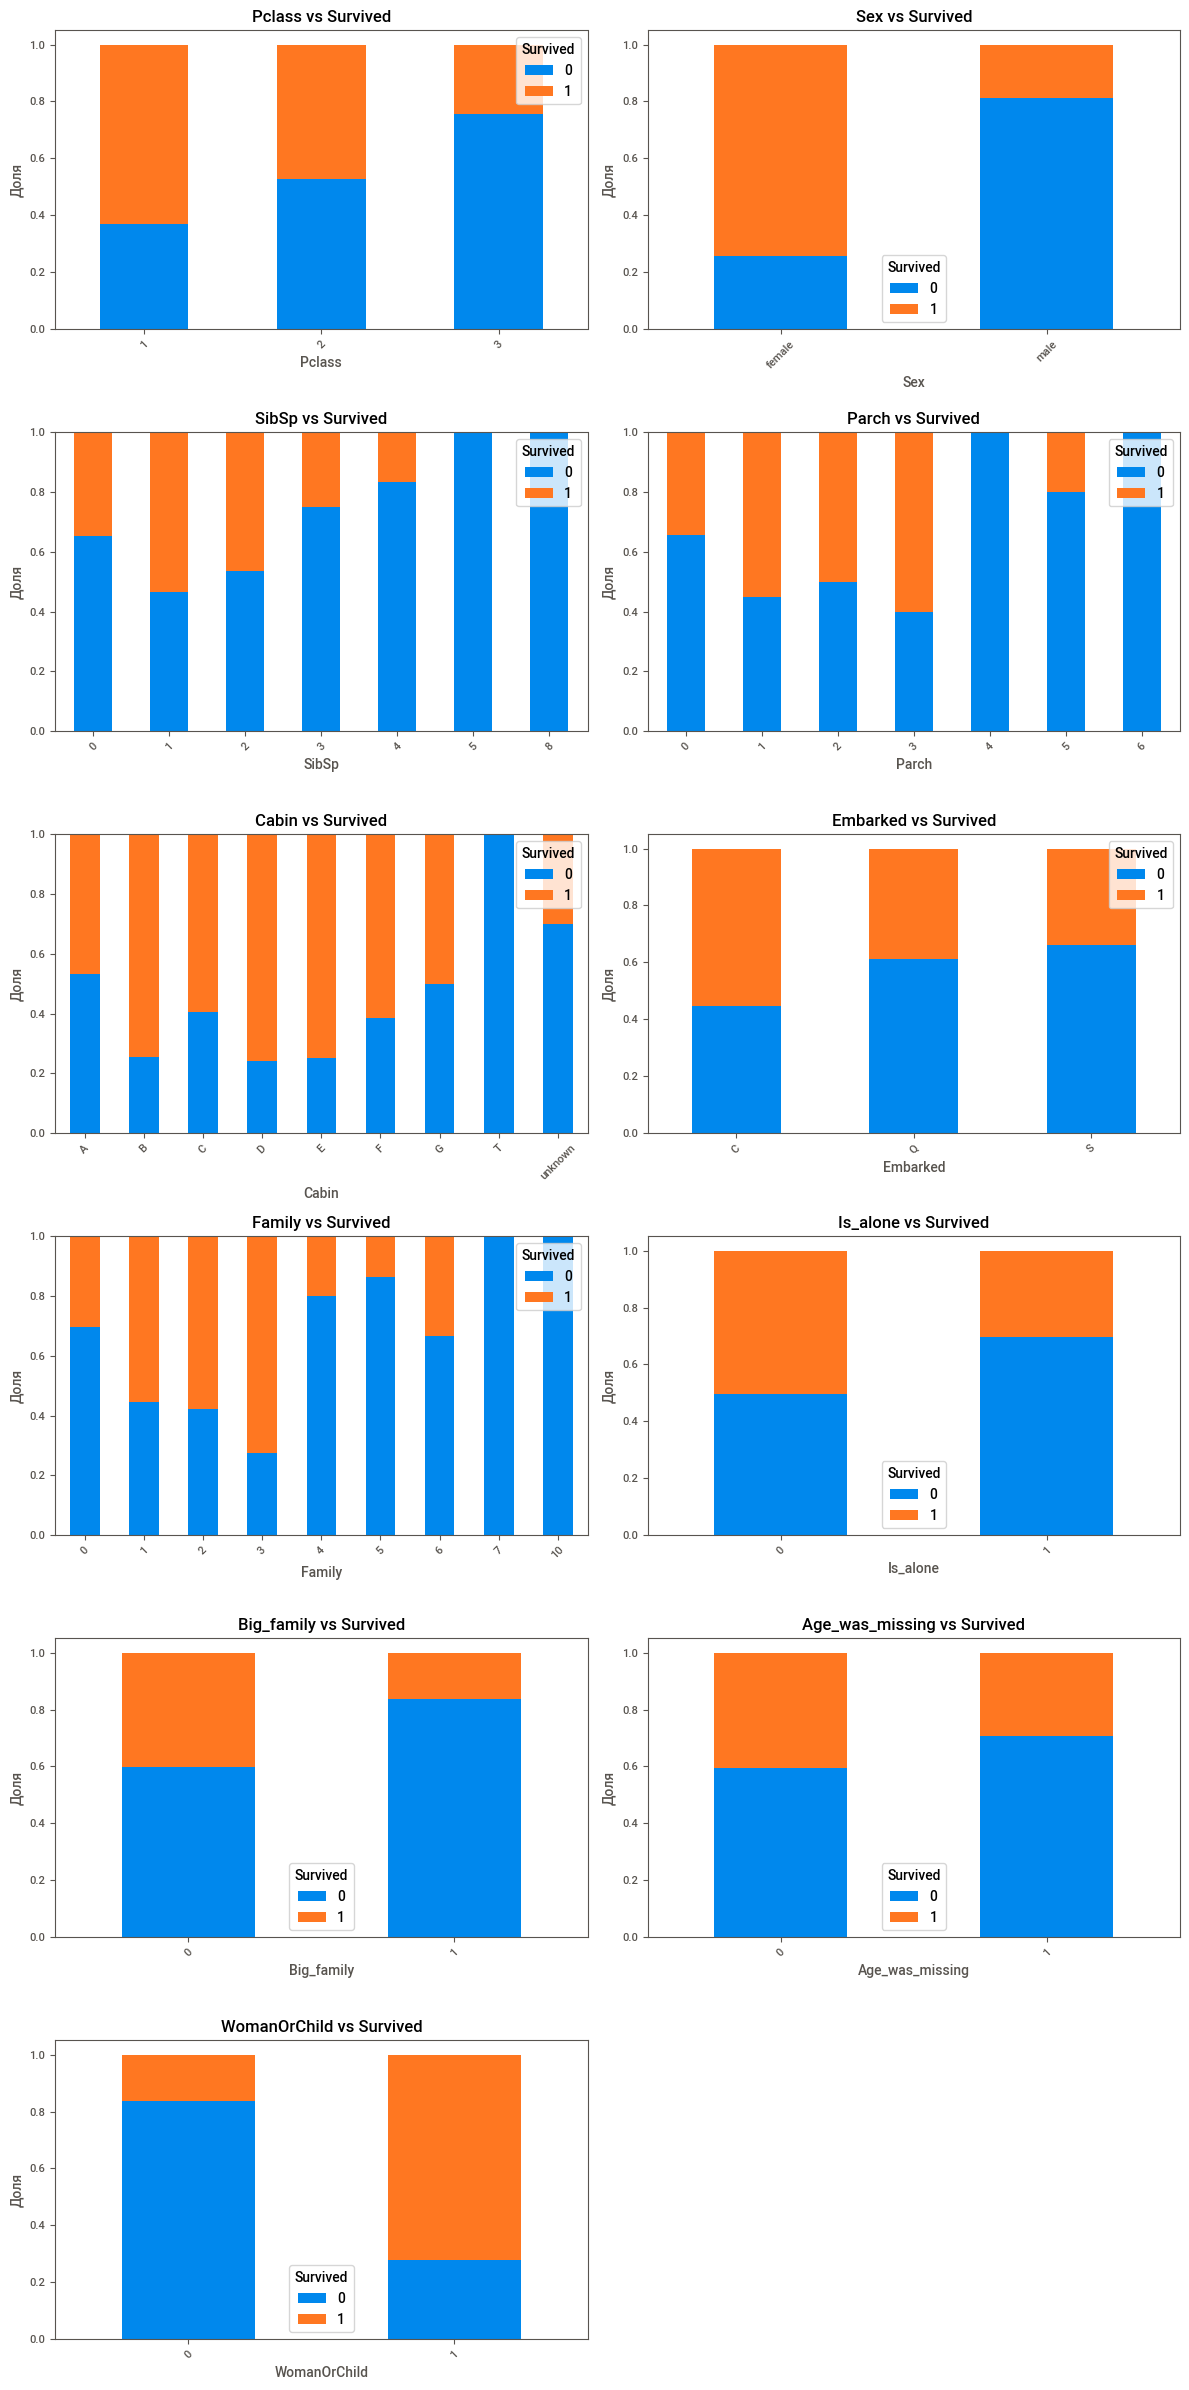

In [14]:
import math
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_target_by_categorical(
    df: pd.DataFrame,
    categorical_features: list,
    target: str = "Survived",
    normalize: bool = True,
    max_categories: int = 15,
    figsize_per_plot: tuple = (6, 4),
    sort_by_target_rate: bool = False
):
    """
    Рисует распределение target по каждому категориальному признаку.
    """

    features = [col for col in categorical_features if col in df.columns and col != target]
    if not features:
        raise ValueError("Не найдено ни одного корректного категориального признака.")

    n = len(features)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows)
    )
    axes = axes.flatten() if n > 1 else [axes]

    for ax, feature in zip(axes, features):
        temp = df[[feature, target]].copy()
        temp[feature] = temp[feature].fillna("Missing")

        # если категорий слишком много — берём top-N
        top_categories = temp[feature].value_counts().head(max_categories).index
        temp = temp[temp[feature].isin(top_categories)]

        ct = pd.crosstab(temp[feature], temp[target])

        if sort_by_target_rate and 1 in ct.columns:
            target_rate = ct[1] / ct.sum(axis=1)
            ct = ct.loc[target_rate.sort_values(ascending=False).index]

        if normalize:
            plot_data = ct.div(ct.sum(axis=1), axis=0)
            ylabel = "Доля"
        else:
            plot_data = ct
            ylabel = "Количество"

        plot_data.plot(
            kind="bar",
            stacked=True,
            ax=ax
        )

        ax.set_title(f"{feature} vs {target}")
        ax.set_xlabel(feature)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=45)
        ax.legend(title=target)

    # удалить лишние пустые оси
    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


def plot_pairwise_numeric_by_target(
    df: pd.DataFrame,
    numeric_features: list,
    target: str = "Survived",
    dropna: bool = True,
    diag_kind: str = "hist",
    corner: bool = True,
    height: float = 2.8
):
    """
    Строит попарные scatter-графики числовых признаков
    с раскраской по target.
    """

    features = [col for col in numeric_features if col in df.columns and col != target]
    if len(features) < 2:
        raise ValueError("Нужно минимум 2 числовых признака для попарного scatter plot.")

    plot_df = df[features + [target]].copy()

    if dropna:
        plot_df = plot_df.dropna()

    sns.pairplot(
        plot_df,
        vars=features,
        hue=target,
        diag_kind=diag_kind,
        corner=corner,
        height=height
    )

    plt.show()

categorical_features = ["Sex", "Pclass", "Embarked", "Cabin", "Ticket"]
numeric_features = ["Age", "Fare", "SibSp", "Parch"]

plot_target_by_categorical(
    df=df_fe,
    categorical_features=cat_cols,
    target="Survived",
    normalize=True,              # доли вместо абсолютных count
    max_categories=10,
    sort_by_target_rate=False
)





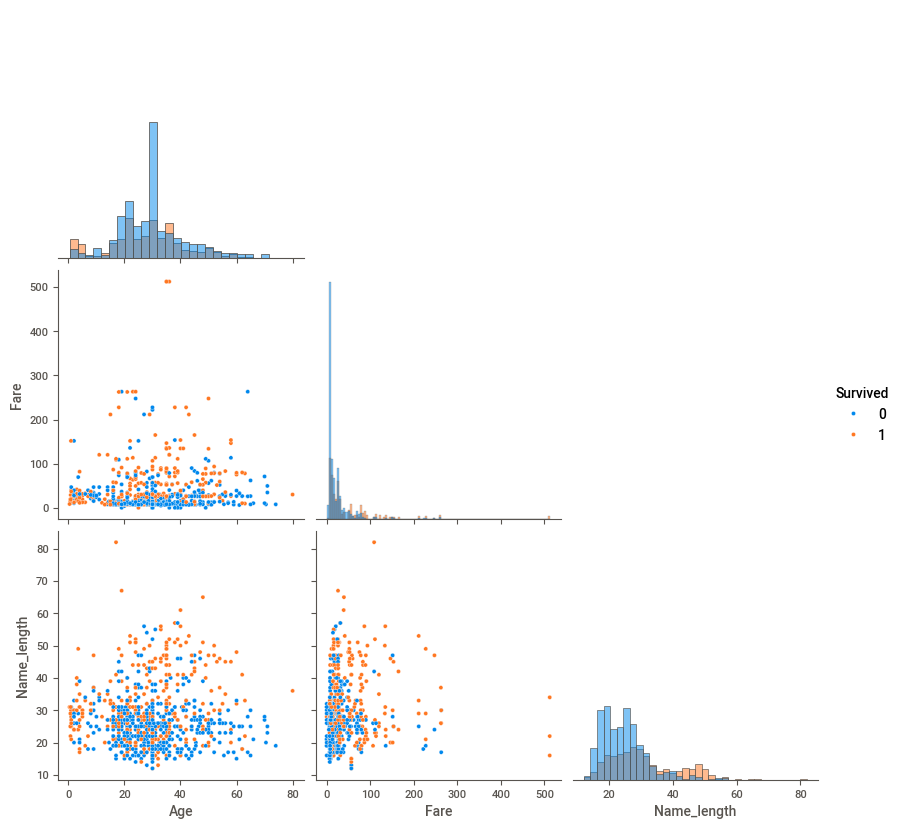

In [15]:
num_cols = [
    'Age',
    'Fare',
    # 'Fare_log',
    # 'Fare_per_person',
    # 'Age_class',
    # 'AgeGroup',
    # 'Fare_class',
    'Name_length',
]
plot_pairwise_numeric_by_target(
    df=df_fe,
    numeric_features=num_cols,
    target="Survived",
    diag_kind="hist",
    corner=True
)

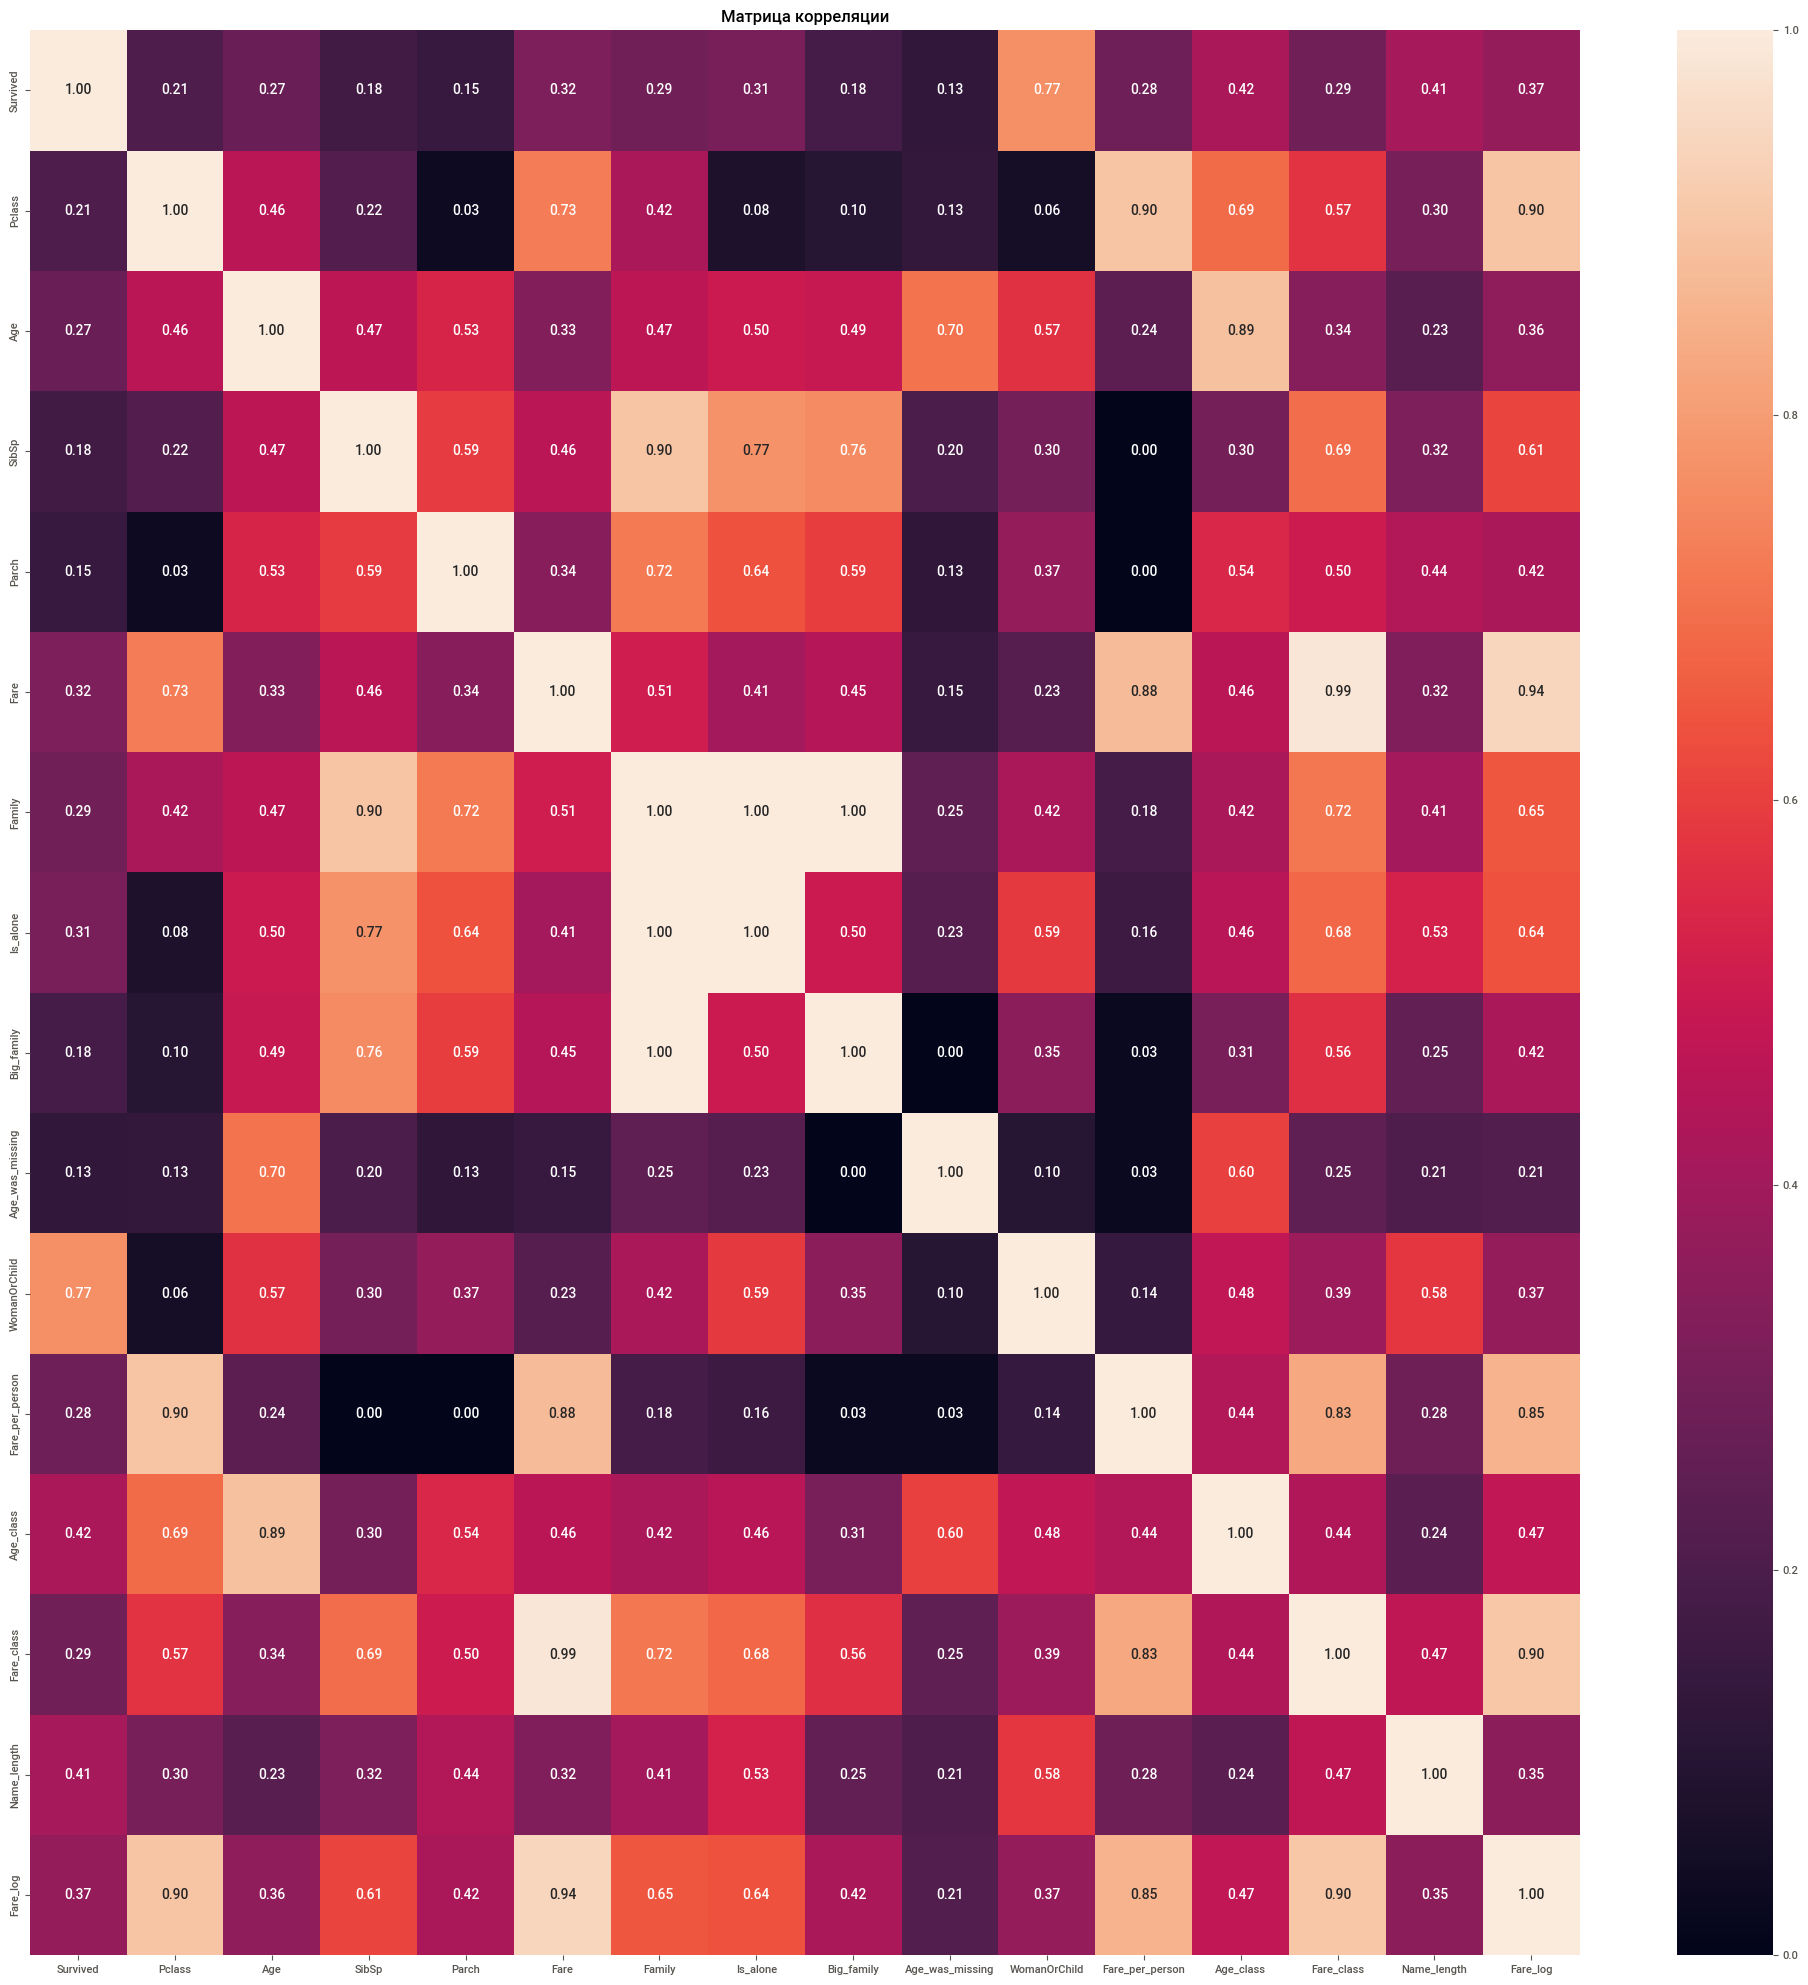

In [16]:
from src.utils import draw_phik_matrix
import phik
draw_phik_matrix(df_fe, drop_columns=['PassengerId'])


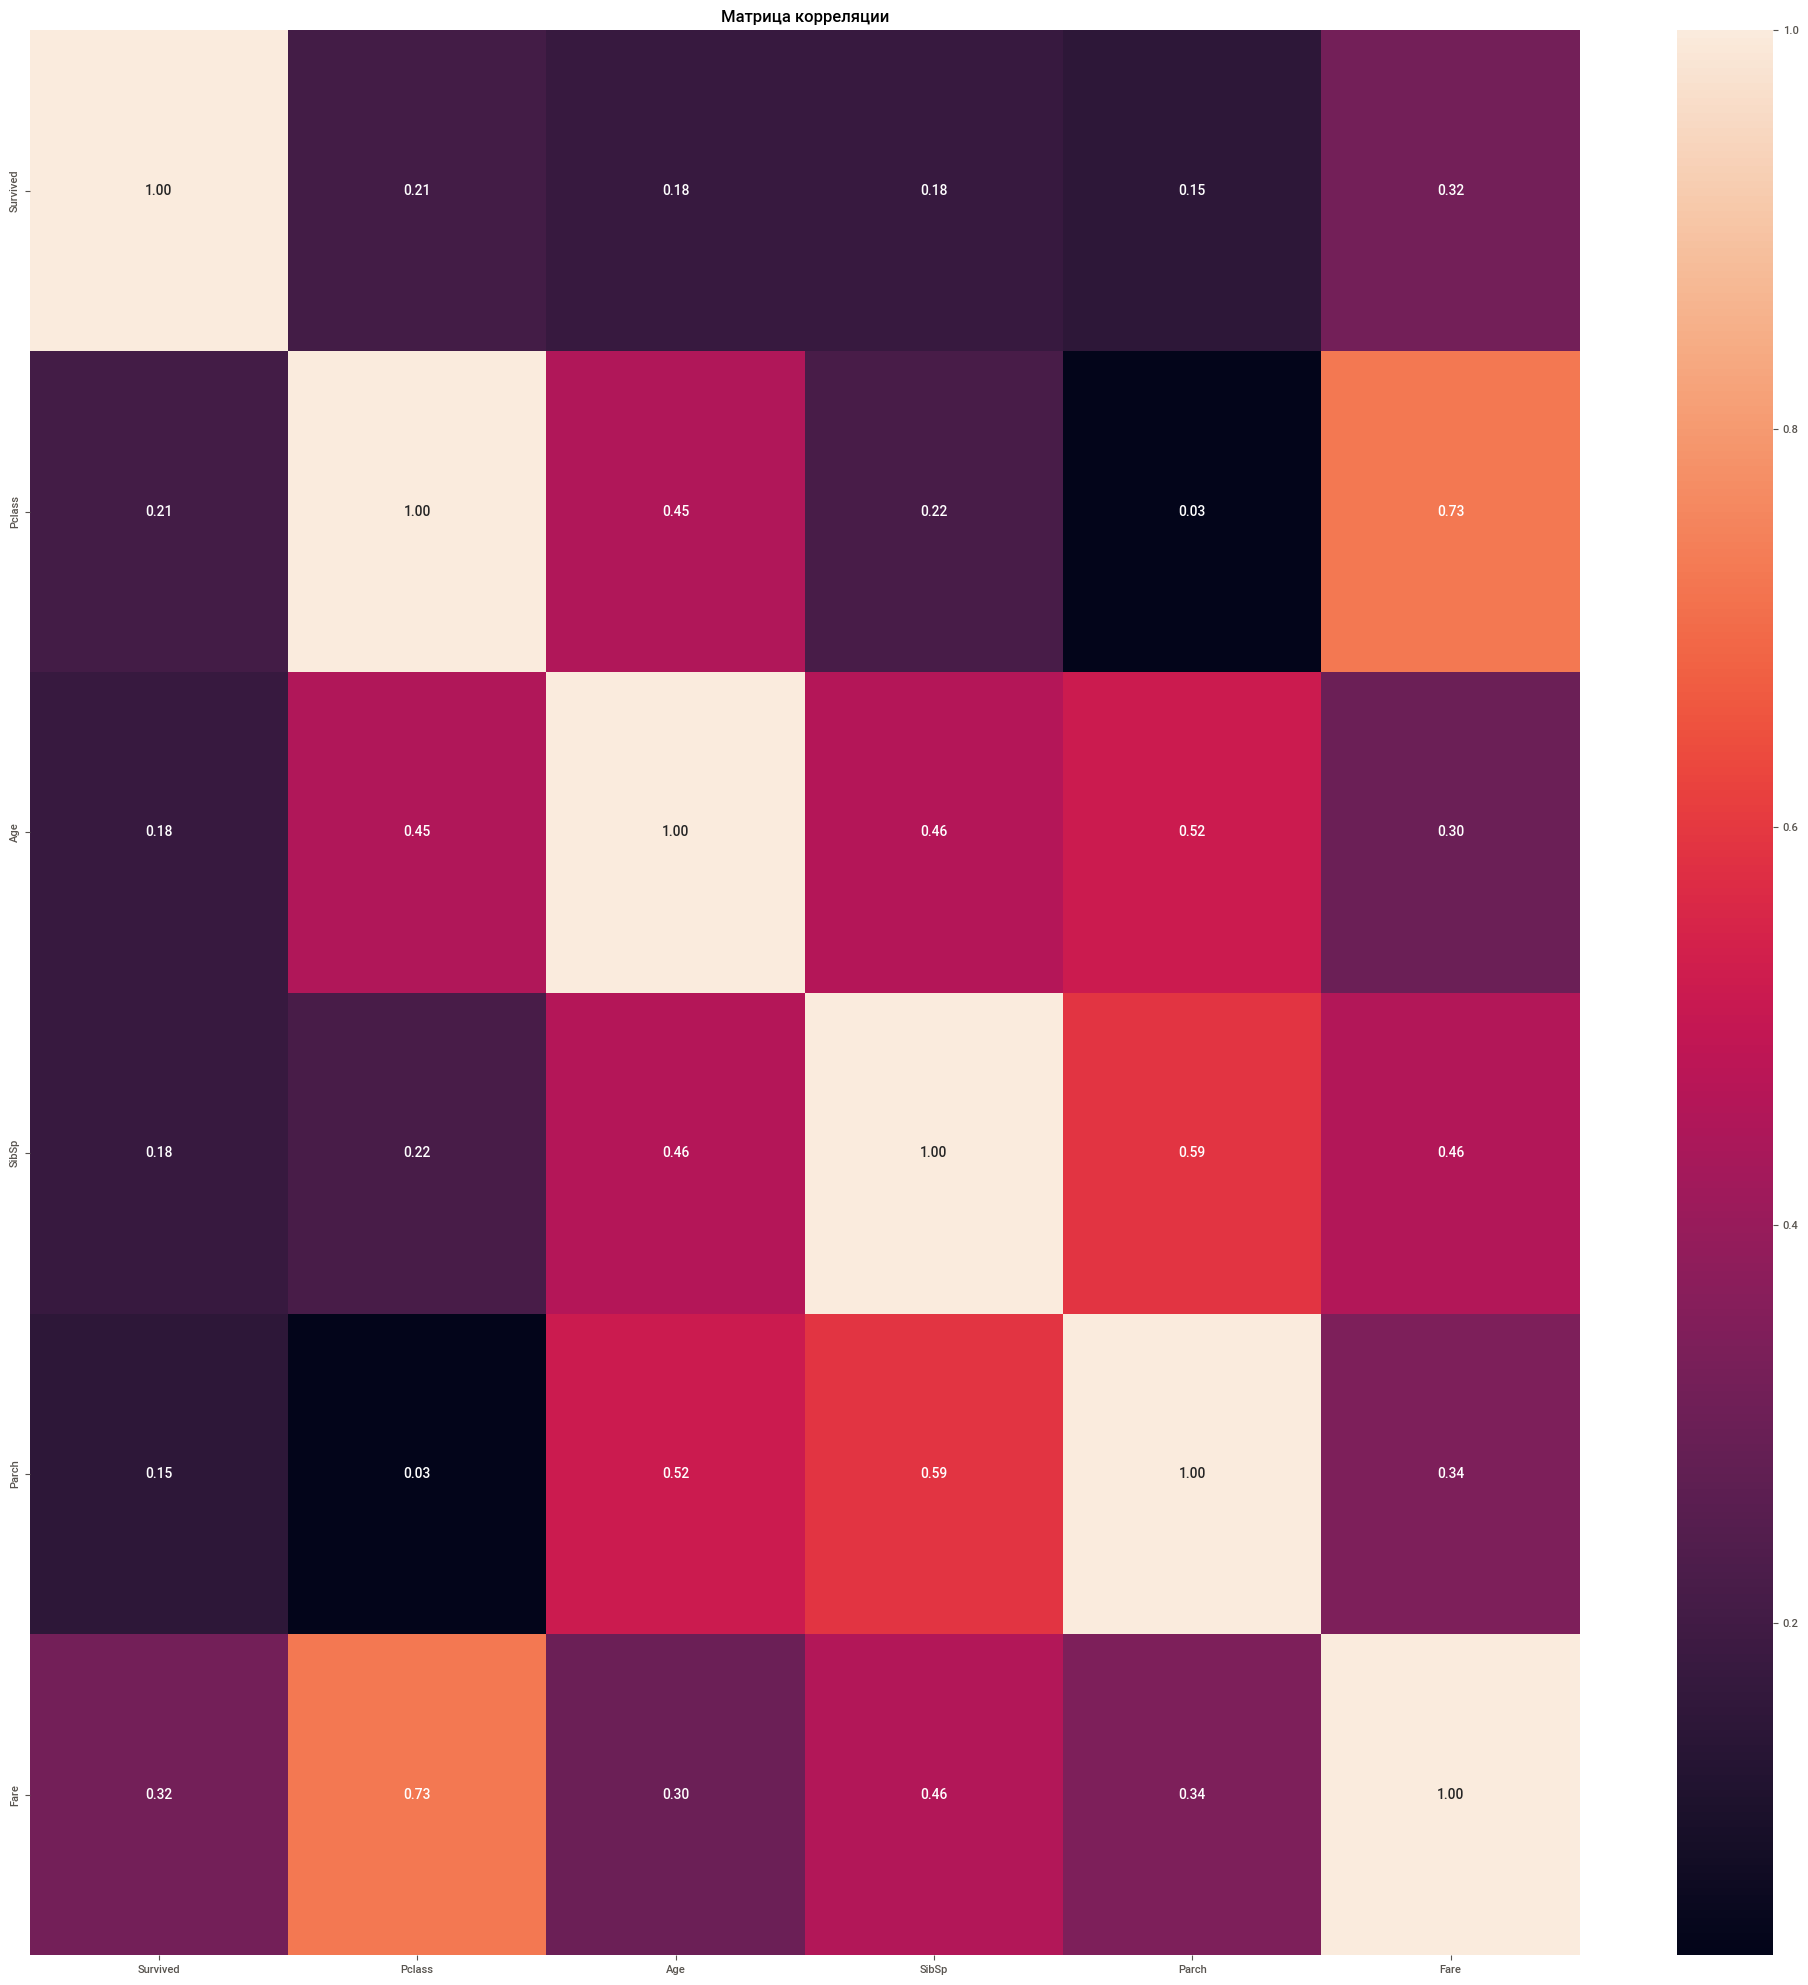

In [17]:
draw_phik_matrix(df, drop_columns=['PassengerId'])

In [43]:
path = config.paths.path_to_checkpoints / 'leaderboard.csv'
leaderboard = pd.read_csv(path)
leaderboard = leaderboard[leaderboard['experiment_name']!=' test']

summary = (
    leaderboard
    .pivot_table(
        index='model_name',
        columns='experiment_name',
        values='score',
        aggfunc='max'
    )
)

summary['max_score'] = summary.max(axis=1)

display(summary.sort_values('max_score', ascending=False))

experiment_name,baseline,v1,v2,max_score
model_name,,,,
RFC,0.854102,0.854096,0.851861,0.854102
DNN,0.848446,0.850712,0.848453,0.850712
GradBC,0.840606,0.841736,0.845101,0.845101
CatBC,0.839483,0.842854,0.842854,0.842854
LogR_elasticnet,0.827142,NaN,0.832760,0.832760
LogR_l1,0.828272,NaN,0.832754,0.832754
LogR,0.829396,0.829396,0.829383,0.829396
KNN,0.822673,0.822660,0.824901,0.824901
